In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

In [6]:
from sklearn.datasets import fetch_california_housing
from sklearn.model_selection import train_test_split


In [7]:
# Load the California housing dataset
data = fetch_california_housing()
X = data.data
y = data.target

In [8]:
# Split the dataset into training and testing sets
X_train,X_test,y_train, y_test = train_test_split(X,y,test_size = 0.2,random_state=42)


In [9]:
# Feature scaling (standardization)
mean = np.mean(X_train, axis=0)
std = np.std(X_train, axis=0)
X_train = (X_train - mean) / std
X_test = (X_test - mean) / std

In [10]:
class LinearRegression:
    def __init__(self,lr = 0.1,epochs = 1000):
        self.lr = lr 
        self.epochs = epochs
        self.weights = None
        self.bias = None
        self.losshistory = []
    
    def fit(self,X,y):
        n_samples, n_features = X.shape
        self.weights = np.zeros(n_features)
        self.bias = 0

        for i in range(self.epochs):
            # Du doan y = Xw + b
            y_predicted = np.dot(X, self.weights) + self.bias
            # Tinh loss (MSE) j = 1/(2m) * sum((y_predicted - y)^2)
            # He so 2 giup khi dao ham ( mu 2 xuong ) thi se triet tieu, nhin dep hon
            loss = (1/n_samples) * np.sum((y_predicted - y) ** 2)
            self.losshistory.append(loss)
            # tinh gradient
            # dw = 1/m * X^T * (y_pred - y)
            dw = (1/n_samples) * np.dot(X.T, (y_predicted - y))
            db = (1/n_samples) * np.sum(y_predicted - y)
            # cap nhat weights va bias
            self.weights -= self.lr * dw
            self.bias -= self.lr * db
            
            if i % 100 == 0:
                print(f'Epoch {i}, Loss: {loss:.4f}')
    def predict(self,X):
        return np.dot(X, self.weights) + self.bias
    
            

In [11]:
model = LinearRegression(lr=0.01, epochs=500)
model.fit(X_train, y_train)

# Danh gia bang r2 score
def r2_score(y_true, y_pred):
    corr_matrix = np.corrcoef(y_true, y_pred)
    return corr_matrix[0, 1] ** 2
y_pred = model.predict(X_test)
print(f'R2 Score: {r2_score(y_test, y_pred):.4f}')

Epoch 0, Loss: 5.6297
Epoch 100, Loss: 1.3040
Epoch 200, Loss: 0.7122
Epoch 300, Loss: 0.6191
Epoch 400, Loss: 0.5954
R2 Score: 0.5457


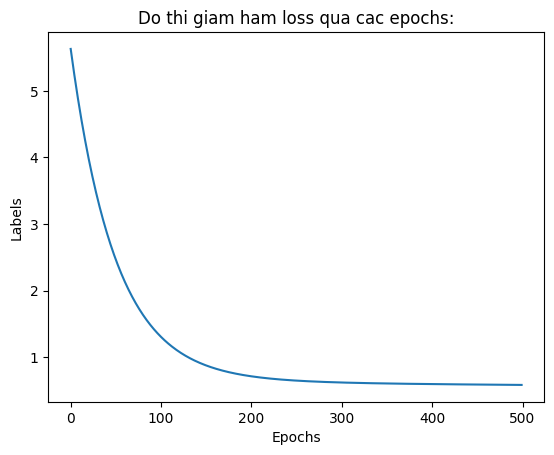

In [13]:
plt.plot(model.losshistory)
plt.title("Do thi giam ham loss qua cac epochs:")
plt.xlabel("Epochs")
plt.ylabel("Labels")
plt.show()